# **E-Commerce Customer Segmentation and Prediction**
Objective:
To segment customers based on purchasing behavior using RFM analysis and predict customer segments using machine learning models.

## Table of Contents

1. Introduction
2. Data Loading
3. Data Understanding
4. Data Cleaning and Create Working Copy of Dataset
5. Clean Data Check
6. Feature Engineering
7. Exploratory Data Analysis (EDA)
8. RFM Analysis
9. Log Transformation
10. Feature Scaling
11. Customer Segmentation Using Clustering

    * 11.1 K-Means Clustering
    * 11.2 Hierarchical Clustering
    * 11.3 DBSCAN
12. Train-Test Split
13. Prediction Models
14. Evaluation Metrics
16. Clustering Algorithm Comparison and Final Selection
16. Business Recommendations
17. Customer Segmentation Dashboard
18. Conclusion






**1. Introduction**

Customer segmentation is a crucial strategy in e-commerce that helps businesses understand customer purchasing behavior and design targeted marketing campaigns. By identifying groups of customers with similar characteristics, companies can improve customer retention, increase sales, and optimize marketing resources.

The objective of this project is to perform customer segmentation using RFM (Recency, Frequency, Monetary) analysis and clustering techniques. Furthermore, machine learning models are developed to predict customer segments based on their purchasing behavior. The insights generated from this project can help businesses personalize marketing efforts and improve customer engagement.

**2. Data Loading**

The dataset used in this project contains transactional records from an online retail store. The dataset includes information such as invoice numbers, product details, quantities purchased, purchase dates, customer identifiers, and country information.

The data was loaded using the Pandas library. During loading, the 'latin1' encoding format was used to handle special characters present in the dataset. Initial exploration was performed to understand the dataset structure, dimensions, data types, and missing values.

In [1]:
# ==============================
# Data Handling
# ==============================
import pandas as pd
import numpy as np

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Feature Scaling
# ==============================
from sklearn.preprocessing import StandardScaler

# ==============================
# Clustering Algorithms
# ==============================
from sklearn.cluster import ( KMeans,  AgglomerativeClustering, DBSCAN)
# ==============================
# Train Test Split
# ==============================
from sklearn.model_selection import train_test_split
# ==============================
# Classification Models
# ==============================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ( RandomForestClassifier, GradientBoostingClassifier)
from sklearn.neighbors import KNeighborsClassifier
# ==============================
# Evaluation Metrics
# ==============================
from sklearn.metrics import ( accuracy_score, classification_report,  confusion_matrix, silhouette_score,
    precision_score,
    recall_score,
    f1_score)

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
df = pd.read_csv( '/content/drive/MyDrive/BIA Project/data.csv',  encoding='latin1')

**3. Data Understanding**

In [4]:
df.shape

(541909, 8)

In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [8]:
df.duplicated().sum() # get all the data which have same value in all the columns

np.int64(5268)

In [9]:
df[df['CustomerID'].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom


In [10]:
df['CustomerID'].isnull().sum()

np.int64(135080)

In [11]:
(df['Quantity'] < 0).sum() #<0 becase Return, Refunds, Cancelled are stored in negative values

np.int64(10624)

In [12]:
df['InvoiceNo'].astype(str).str.startswith('C').sum() # to check cancelled invoices

np.int64(9288)

In [13]:
df['CustomerID'].nunique()

4372

In [14]:
(df['UnitPrice'] <= 0).sum()

np.int64(2517)

**4. Data Cleaning and Create Working Copy of Dataset**

Data cleaning was performed to ensure the quality and reliability of the analysis. Duplicate records were identified and removed to avoid biased results. Records with missing CustomerID values were removed because customer identification is essential for segmentation analysis.

Cancelled invoices, identified by invoice numbers starting with the letter 'C', were excluded from the dataset since they do not represent actual purchases. Records with negative or zero quantities and invalid unit prices were also removed. After cleaning, the dataset contained only valid customer purchase transactions suitable for analysis.

In [15]:
df_clean = df.copy()

In [16]:
df_clean = df_clean.drop_duplicates()

In [17]:
df_clean.shape

(536641, 8)

In [18]:
df_clean = df_clean.dropna(subset=['CustomerID'])

In [19]:
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')] # as mentioned invoice no which starts from C are Cancelled

In [20]:
df_clean = df_clean[df_clean['Quantity'] > 0] # all the data in quantity which are 0 or less than 0 will be removed

In [21]:
df_clean = df_clean[df_clean['UnitPrice'] > 0]

**5. Clean Data Check**

In [22]:
df_clean.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [23]:
(df_clean['Quantity'] < 0).sum()

np.int64(0)

In [24]:
(df_clean['UnitPrice'] <= 0).sum()

np.int64(0)

In [25]:
df_clean['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(0)

**6. Feature Engineering**

In [26]:
df_clean['TotalAmount'] = ( df_clean['Quantity'] * df_clean['UnitPrice'])

In [27]:
df_clean[['Quantity','UnitPrice','TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [28]:
df_clean['CustomerID'].nunique()

4338

In [29]:
df_clean.to_csv( '/content/drive/MyDrive/BIA Project/Cleaned_Ecommerce_Data.csv', index=False)

In [30]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


**7. Exploratory Data Analysis (EDA)**

Exploratory Data Analysis was conducted to understand customer purchasing patterns and sales trends. Revenue distribution across countries was analyzed to identify major markets. Product-level analysis was performed to determine the highest revenue-generating products.

EDA helped reveal important business insights, including customer concentration within specific regions and the contribution of key products to overall sales. These findings provided valuable context before proceeding with customer segmentation.

In [31]:
df_clean.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

,TotalAmount
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


In [32]:
df_clean.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(10)

,TotalAmount
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,100392.10
JUMBO BAG RED RETROSPOT,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68785.23
ASSORTED COLOUR BIRD ORNAMENT,56413.03
Manual,53419.93


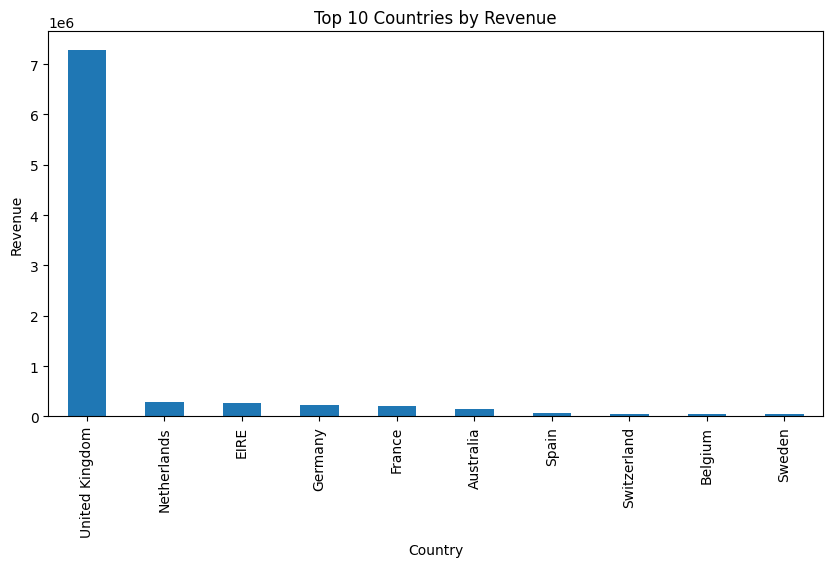

In [33]:
country_sales = (df_clean.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(10,5))
country_sales.plot(kind='bar')
plt.title('Top 10 Countries by Revenue')
plt.ylabel('Revenue')
plt.show()

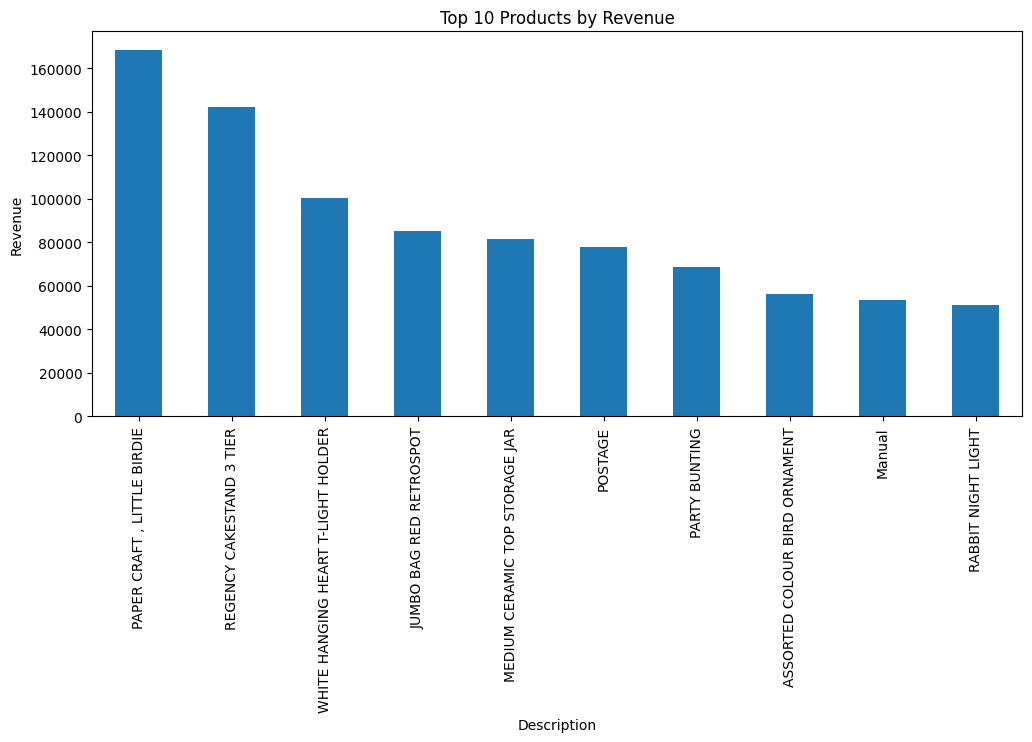

In [34]:
product_sales = (df_clean.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(12,5))
product_sales.plot(kind='bar')
plt.title('Top 10 Products by Revenue')
plt.ylabel('Revenue')
plt.show()

**8. RFM Analysis**

RFM Analysis is a customer segmentation technique based on three behavioral metrics:

• Recency – Number of days since the customer's most recent purchase.

• Frequency – Number of unique purchase transactions made by the customer.

• Monetary – Total amount spent by the customer.

RFM analysis transforms transactional data into customer-level behavioral data. Customers with lower recency values, higher purchase frequency, and higher monetary values are generally considered more valuable to the business. The RFM table created in this project formed the foundation for customer segmentation.

In [35]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [36]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1) # to get latest purchase date

rfm = df_clean.groupby('CustomerID').agg({'InvoiceDate': lambda x: (snapshot_date - x.max()).days,'InvoiceNo': 'nunique',
                                          'TotalAmount': 'sum'})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head() # recency i sthe data where most recent pruchase last date is counted from  snapshot date and freuqnece is the amount of times that smae cusromer purchse the items(n number of times)

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [37]:
rfm.shape

(4338, 3)

In [38]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [39]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


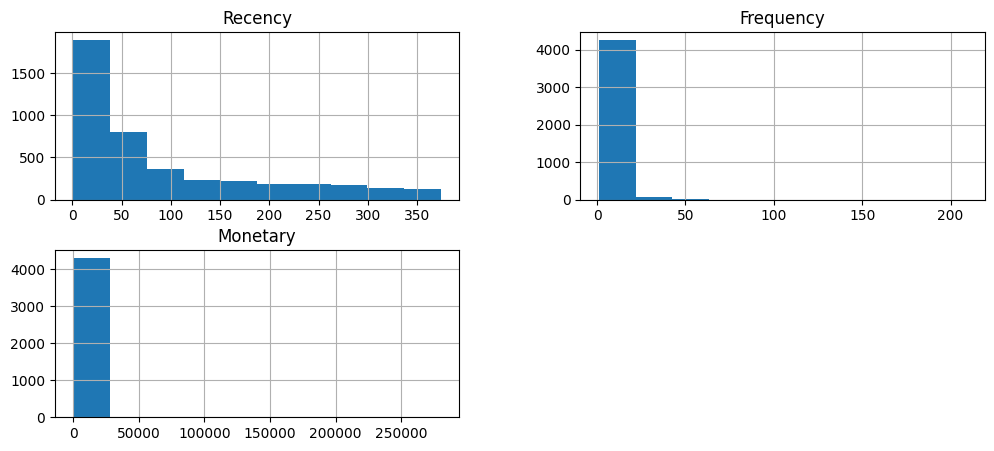

In [40]:
rfm.hist(figsize=(12,5))
plt.show()

**9. Log Transformation
Log Scaling
Log Normalization**

def-
Purpose:
Reduce skewness
Compress huge values

Range:
Not fixed

Used for:
Sales
Income
Revenue
Customer Spending

In [41]:
#K-Means will focus almost entirely on Monetary and ignore Recency and Frequency.
rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

**10. Feature Scaling**

The RFM variables have different numerical ranges. For example, Monetary values can be significantly larger than Recency and Frequency values. If left unscaled, clustering algorithms may assign excessive importance to the Monetary feature.

To address this issue, StandardScaler was applied to standardize the RFM features. This transformation ensures that all variables contribute equally to distance calculations used by clustering algorithms and machine learning models.

In [42]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

In [43]:
rfm_scaled[:5]

array([[ 1.46199281, -0.95521426,  3.7077163 ],
       [-2.03873442,  1.07442519,  1.41490344],
       [ 0.37310424,  0.38630445,  0.72002428],
       [-0.62308592, -0.95521426,  0.70228691],
       [ 1.42455753, -0.95521426, -0.61451388]])

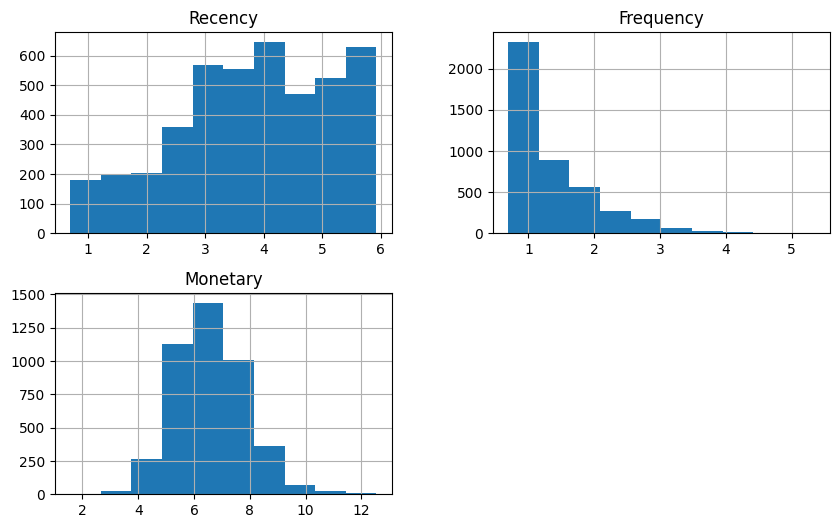

In [44]:
rfm_log.hist(figsize=(10,6))
plt.show()

**11. Customer Segmentation Using Clustering**

Customer segmentation was performed using clustering techniques on the scaled RFM data. K-Means clustering was selected as the primary segmentation approach. The optimal number of clusters was determined using the Elbow Method and Silhouette Score analysis.

The final clustering process identified four meaningful customer segments:

• VIP Customers

• Loyal Customers

• Potential Customers

• At-Risk Customers

Each segment represents a distinct purchasing behavior pattern and provides actionable business insights.
Three clustering techniques were evaluated in this project:

• K-Means Clustering

• Hierarchical Clustering

• DBSCAN

K-Means produced the most balanced and interpretable customer segments. Hierarchical Clustering generated similar customer groupings but required higher computational effort. DBSCAN successfully identified outlier customers; however, it produced less meaningful business segments for this dataset.

Based on the quality and interpretability of the generated segments, *`K-Means was selected as the preferred clustering technique.`*

**11.1  K-Means Clustering**

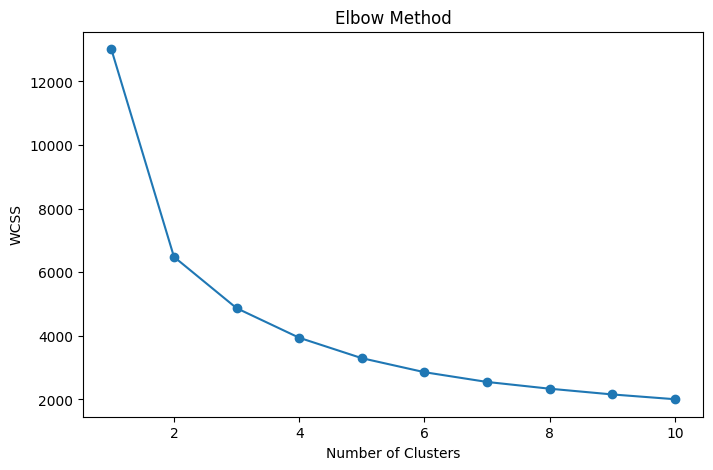

In [45]:
wcss = []

for i in range(1,11):
    kmeans = KMeans( n_clusters=i, random_state=42,  n_init=10)

    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

**11.1.1  The Silhouette Score**

In [46]:
for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    print(f'K={k}, Score={score:.4f}')

K=2, Score=0.4328
K=3, Score=0.3365
K=4, Score=0.3375
K=5, Score=0.3162
K=6, Score=0.3124
K=7, Score=0.3092
K=8, Score=0.3033
K=9, Score=0.2811
K=10, Score=0.2767


The Silhouette Score was highest for K=2 (0.4328), indicating the strongest cluster separation. However, K=4 was selected because it provided more actionable customer segments while maintaining reasonable cluster quality. This enabled meaningful business categorization such as VIP, Loyal, Regular, and At-Risk customers.


In [47]:
kmeans = KMeans( n_clusters=4,  random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [48]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,2
12350.0,310,1,334.40,1


In [49]:
rfm['Cluster'].value_counts()

,count
Cluster,
1,1622
3,1166
2,837
0,713


In [50]:
cluster_summary = rfm.groupby('Cluster').agg({ 'Recency':'mean',  'Frequency':'mean',  'Monetary':'mean'}).round(2)
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,12.17,13.75,8088.02
1,181.51,1.32,341.00
2,17.70,2.19,557.32
3,71.64,4.08,1801.78


Cluster	Label
0	VIP Customers
3	Loyal Customers
2	New / Potential Customers
1	Lost / At-Risk Customers

VIP Customers (0)

713 Customers

Actions:

Exclusive discounts
Loyalty rewards
Early access sales
Premium support
Loyal Customers (3)

1166 Customers

Actions:

Upselling
Cross-selling
Membership programs
Potential Customers (2)

837 Customers

Actions:

Welcome campaigns
Product recommendations
First-repeat-purchase discounts
Lost Customers (1)

1622 Customers

Actions:

Win-back campaigns
Email reminders
Special offers

In [51]:
rfm.to_csv('/content/drive/MyDrive/BIA Project/clustered_customers.csv',index=False)

In [52]:
cluster_names = {
    0:'VIP',
    1:'At Risk',
    2:'Potential',
    3:'Loyal'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

In [53]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Loyal
12347.0,2,7,4310.00,0,VIP
12348.0,75,4,1797.24,3,Loyal
12349.0,19,1,1757.55,2,Potential
12350.0,310,1,334.40,1,At Risk


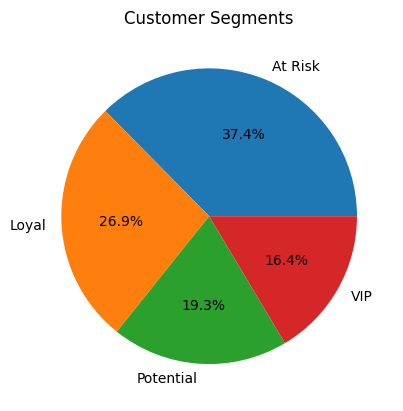

In [54]:
rfm['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Customer Segments')
plt.show()

In [55]:
segment_profile = rfm.groupby('Segment').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}).round(2)

segment_profile

,Recency,Frequency,Monetary
Segment,,,
At Risk,181.51,1.32,341.00
Loyal,71.64,4.08,1801.78
Potential,17.70,2.19,557.32
VIP,12.17,13.75,8088.02


In [56]:
X = rfm[['Recency','Frequency','Monetary']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**11.2 Hierarchical Clustering**

In [57]:
hc = AgglomerativeClustering(n_clusters=4)
rfm['HC_Cluster'] = hc.fit_predict(X_scaled)

In [58]:
rfm['HC_Cluster'].value_counts()

,count
HC_Cluster,
1,3042
2,1134
3,147
0,15


**11.3 DBSCAN**

In [59]:
dbscan = DBSCAN( eps=0.5, min_samples=5)
rfm['DBSCAN_Cluster'] = ( dbscan.fit_predict(X_scaled))

In [60]:
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)
rfm['DBSCAN_Cluster'].value_counts()

,count
DBSCAN_Cluster,
0,4284
-1,54


**High-Value Customer Analysis (Data Leakage Demonstration)**

HighValue =
(
 Monetary > 75th percentile
 AND
 Frequency > median
 AND
 Recency < median
)

Note:
This section is included to demonstrate how data leakage can lead to unrealistically high model performance. Therefore, customer clusters generated through K-Means were selected as the final prediction target.

In [61]:
rfm['HighValueCustomer'] = (
    rfm['Monetary']
    > rfm['Monetary'].quantile(0.75)
).astype(int)

In [62]:
rfm['HighValueCustomer'].value_counts()

,count
HighValueCustomer,
0,3253
1,1085


In [63]:
X = rfm[['Recency','Frequency','Monetary']]
y = rfm['Cluster']
# y = rfm['HC_Cluster']
# y = rfm['DBSCAN_Cluster']


In [64]:
X_scaled = pd.DataFrame( X_scaled, columns=X.columns)

**12. Train-Test Split**

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42,  stratify=y)

**13. Prediction Models**

After generating customer segments through clustering, several supervised machine learning models were trained to predict customer segment membership. The models evaluated in this project include:

• Logistic Regression

• K-Nearest Neighbors (KNN)

• Decision Tree

• Random Forest

• Gradient Boosting

The input features used for prediction were Recency, Frequency, and Monetary values, while the target variable was the customer segment identified through clustering.

In [66]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

**14. Evaluation Metrics**

Each model was evaluated using the following performance metrics:

• Accuracy – Overall percentage of correct predictions.
• Precision – Measures how many predicted customer segments were correctly classified.
• Recall – Measures how many actual customer segments were successfully identified.
• F1-Score – Harmonic mean of Precision and Recall, providing a balanced evaluation metric.

The results are compared to determine the best-performing model for predicting customer segments generated through clustering.

In [69]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append([
        name,
        *[
            metric(y_test, y_pred, average='weighted')
            if metric != accuracy_score
            else metric(y_test, y_pred)
            for metric in [accuracy_score, precision_score, recall_score, f1_score]
        ]
    ])

comparison = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
).sort_values('Accuracy', ascending=False)

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.9700,0.9707,0.9700,0.9702
4,Gradient Boosting,0.9700,0.9708,0.9700,0.9702
1,Decision Tree,0.9562,0.9564,0.9562,0.9562
3,KNN,0.9459,0.9461,0.9459,0.9457
0,Logistic Regression,0.9263,0.9282,0.9263,0.9260


In [73]:
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Feature importance analysis revealed that Recency was the most influential factor (40.7%) in determining customer segment membership, followed by Monetary value (33.0%) and Frequency (26.3%). This indicates that recent customer engagement is a stronger indicator of customer value than historical spending alone.

In [75]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
0,Recency,0.407056
2,Monetary,0.329679
1,Frequency,0.263265


**15. Key Points**

Four customer segments identified:
VIP
Loyal
Potential
At Risk

Largest segment:
At Risk Customers

Most important predictor:
Recency

Model accuracy:
97%







**16. Business Recommendations**

Based on the identified customer segments, the following business recommendations are proposed:

VIP Customers:
Provide loyalty rewards, premium offers, and exclusive promotions to maintain engagement.

Loyal Customers:
Encourage repeat purchases through cross-selling and membership programs.

Potential Customers:
Offer personalized recommendations and targeted campaigns to increase purchase frequency.

At-Risk Customers:
Implement win-back campaigns, discounts, and reminder communications to re-engage inactive customers.

In [76]:
import joblib

# Train final model
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train)

# Save in Google Drive
joblib.dump( best_model,'/content/drive/MyDrive/BIA Project/customer_segmentation_model.pkl')
print("Model saved successfully!")

Model saved successfully!


**17. Customer Segmentation Dashboard**

In [77]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import pandas as pd

# If CustomerID is index
# rfm = rfm.reset_index()

# =====================================
# Customer ID Input
# =====================================

customer_id = widgets.Text(
    description='Customer ID:',
    placeholder='Enter CustomerID'
)

# =====================================
# Manual Input Sliders
# =====================================

recency = widgets.IntSlider(
    value=30,
    min=1,
    max=250,
    description='Recency'
)

frequency = widgets.IntSlider(
    value=5,
    min=1,
    max=12,
    description='Frequency'
)

monetary = widgets.FloatSlider(
    value=1000,
    min=1,
    max=6000,
    description='Monetary'
)

# =====================================
# Buttons
# =====================================

button_customer = widgets.Button(
    description='Search Customer',
    button_style='info'
)

button_predict = widgets.Button(
    description='Predict Segment',
    button_style='success'
)

output = widgets.Output()

# =====================================
# Labels
# =====================================

labels = {
    0: "VIP Customer",
    1: "At-Risk Customer",
    2: "Potential Customer",
    3: "Loyal Customer"
}

descriptions = {
    0: "High spending and highly engaged customers.",
    1: "Inactive customers requiring re-engagement.",
    2: "Customers with growth potential.",
    3: "Consistent repeat customers."
}

segment_colors = {
    0: "#15803d",   # Green
    1: "#dc2626",   # Red
    2: "#ca8a04",   # Yellow
    3: "#2563eb"    # Blue
}

# =====================================
# Search Customer
# =====================================

def search_customer(b):

    with output:

        clear_output()

        try:

            cid = float(customer_id.value)

            customer = rfm[
                rfm['CustomerID'] == cid
            ]

            if len(customer) == 0:

                print("Customer not found.")

            else:

                display(
                    HTML(f"""
                    <div style="
                    background:#0f172a;
                    color:white;
                    padding:20px;
                    border-radius:12px;
                    border:2px solid #2563eb;
                    font-size:16px;
                    ">

                    <h2 style="color:#60a5fa;">
                    👤 Customer Profile
                    </h2>

                    <b>Customer ID:</b>
                    {customer.iloc[0]['CustomerID']}<br><br>

                    <b>Recency:</b>
                    {customer.iloc[0]['Recency']}<br>

                    <b>Frequency:</b>
                    {customer.iloc[0]['Frequency']}<br>

                    <b>Monetary:</b>
                    ₹{customer.iloc[0]['Monetary']:.2f}<br><br>

                    <b>Segment:</b>
                    {labels[customer.iloc[0]['Cluster']]}
                    </div>
                    """)
                )

        except:

            print("Please enter a valid Customer ID.")

# =====================================
# Predict Segment
# =====================================

def predict_customer(b):

    with output:

        clear_output()

        data = pd.DataFrame({
            'Recency': [recency.value],
            'Frequency': [frequency.value],
            'Monetary': [monetary.value]
        })

        cluster = best_model.predict(data)[0]

        display(
            HTML(f"""
            <div style="
            background:{segment_colors[cluster]};
            color:white;
            padding:20px;
            border-radius:12px;
            font-size:26px;
            font-weight:bold;
            text-align:center;
            ">
            🎯 Predicted Segment:
            {labels[cluster]}
            </div>
            """)
        )

        print("\nBusiness Insight:")
        print(descriptions[cluster])

        print("\nInput Values:")
        display(data)

# =====================================
# Events
# =====================================

button_customer.on_click(search_customer)
button_predict.on_click(predict_customer)

# =====================================
# Dashboard Header
# =====================================

display(
    HTML("""
    <h1 style='color:green'>
    Customer Segmentation Dashboard
    </h1>

    <p style='color:gray'>
    Predictions are based on historical customer purchasing behavior.
    Extreme RFM combinations may not exist in the original dataset.
    </p>

    <hr>
    """)
)

# =====================================
# Layout
# =====================================

display(
    customer_id,
    button_customer
)

display(
    recency,
    frequency,
    monetary,
    button_predict
)

display(output)

Text(value='', description='Customer ID:', placeholder='Enter CustomerID')

Button(button_style='info', description='Search Customer', style=ButtonStyle())

IntSlider(value=30, description='Recency', max=250, min=1)

IntSlider(value=5, description='Frequency', max=12, min=1)

FloatSlider(value=1000.0, description='Monetary', max=6000.0, min=1.0)

Button(button_style='success', description='Predict Segment', style=ButtonStyle())

Output()

**18. Conclusion**

This project successfully applied data cleaning, feature engineering, RFM analysis, customer segmentation, and predictive modeling to understand customer purchasing behavior. RFM metrics (Recency, Frequency, and Monetary) were used to capture customer value and purchasing patterns, while K-Means, Hierarchical Clustering, and DBSCAN were evaluated for segmentation.

Among the clustering techniques, K-Means produced the most balanced and business-relevant customer segments by effectively utilizing all three RFM dimensions. The identified segments provide valuable insights for customer retention, personalized marketing, and revenue growth strategies.

Multiple machine learning models were compared for segment prediction, with Random Forest and Gradient Boosting achieving the highest performance. Overall, the project demonstrates how data-driven customer segmentation can support better business decision-making and improve customer relationship management.